In [9]:
import librosa
import librosa.display
import  numpy as np
import matplotlib.pyplot as plt

In [10]:
file = r"C:\Users\Shraddha\Downloads\alexzavesa-calm-inspiring-piano-logo-short-version-518990.mp3"

In [11]:
import soundfile as sf

In [12]:
audio, sr = librosa.load(r"C:\Users\Shraddha\Downloads\alexzavesa-calm-inspiring-piano-logo-short-version-518990.mp3",sr = 16000)

In [13]:
sf.write("audio.wav",audio,sr)

In [14]:
print("Audio shape:",audio.shape)

Audio shape: (128732,)


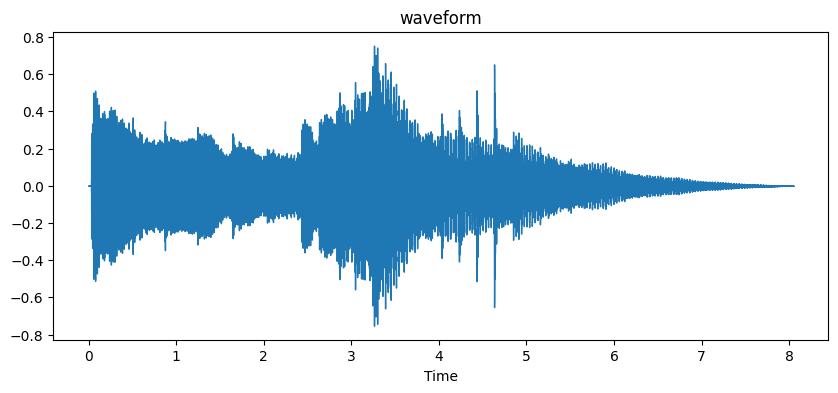

In [15]:
plt.figure(figsize=(10,4))
librosa.display.waveshow(audio,sr=sr)
plt.title("waveform")
plt.show()

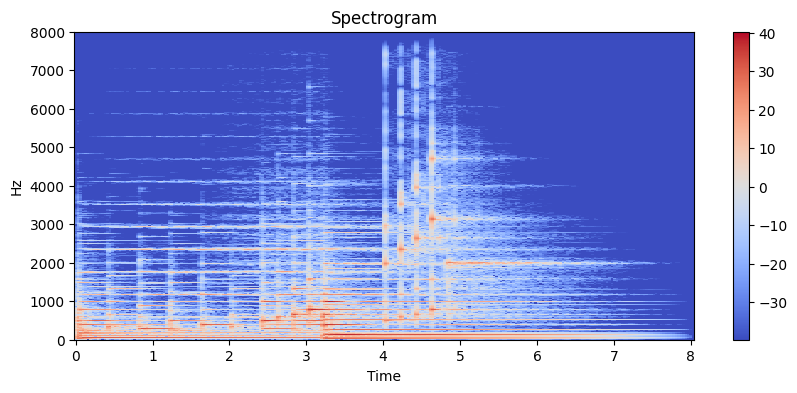

In [16]:
spec = np.abs(librosa.stft(audio))
spec_db = librosa.amplitude_to_db(spec)
plt.figure(figsize=(10,4))
librosa.display.specshow(spec_db,sr=sr,x_axis='time',y_axis='hz')
plt.colorbar()
plt.title("Spectrogram")
plt.show()

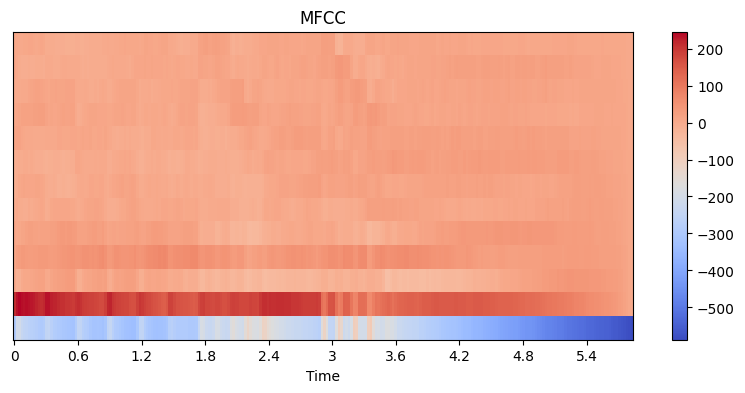

In [18]:
mfcc = librosa.feature.mfcc(y=audio,sr=sr,n_mfcc=13)
plt.figure(figsize=(10,4))
librosa.display.specshow(mfcc,x_axis='time')
plt.colorbar()
plt.title("MFCC")
plt.show()

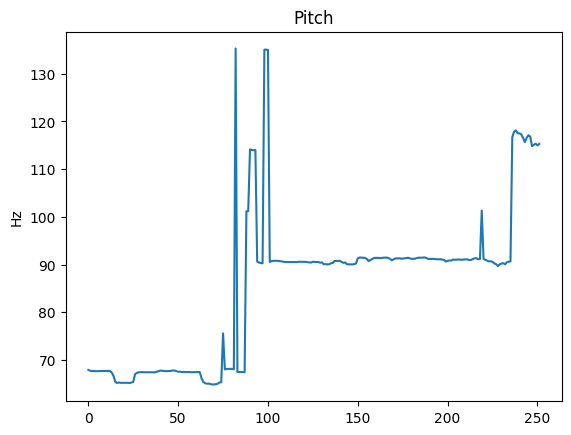

In [19]:
f0 = librosa.yin(audio,fmin=50,fmax=300)
plt.plot(f0)
plt.title("Pitch")
plt.ylabel("Hz")
plt.show()

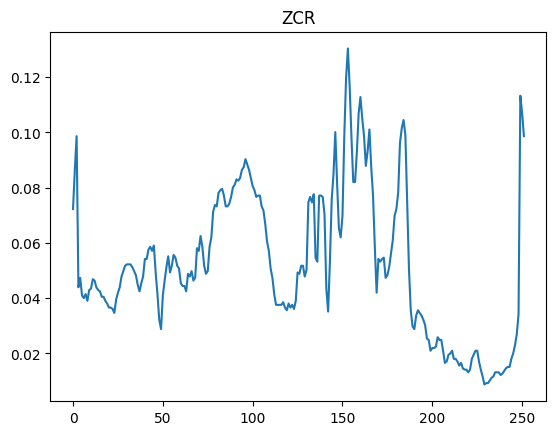

In [20]:
zcr = librosa.feature.zero_crossing_rate(audio)
plt.plot(zcr[0])
plt.title("ZCR")
plt.show()

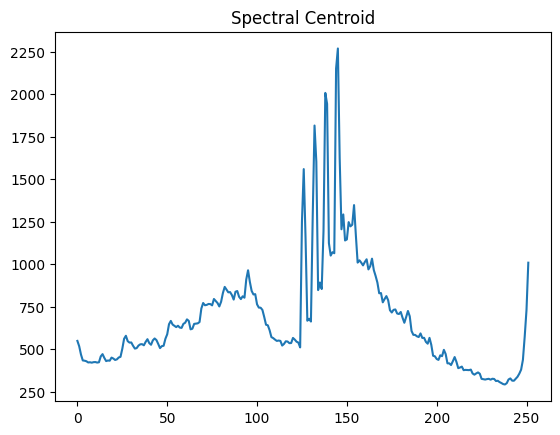

In [21]:
centroid = librosa.feature.spectral_centroid(y=audio,sr=sr)
plt.plot(centroid[0])
plt.title("Spectral Centroid")
plt.show()

In [23]:
tempo, _ = librosa.beat.beat_track(y=audio,sr=sr)
print("Tempo:",tempo,"BPM")

Tempo: [144.23076923] BPM


In [24]:
trimmed_audio,_ = librosa.effects.trim(audio)
print("Original length:",len(audio))
print("Trimmed length:",len(trimmed_audio))

Original length: 128732
Trimmed length: 128000


In [25]:
intervals = librosa.effects.split(audio,top_db=20)
print(intervals[:5])

[[     0 103424]]


In [27]:
segments = []
for start,end in intervals:
    segment = audio[start:end]
    segments.append(segment)
print("Total Segments:", len(segments))

Total Segments: 1
